# FX Carry Strategy — Portfolio Backtest

Implements HANDOFF §5 (roadmap steps 4–6) with the §4 decisions locked:
universe drops pegged HKD/DKK and CNY (CNH is the RMB leg); **G10 track**
(terciles) then **combined G10+EM track** (quintiles); inverse-trailing-vol leg
weights with a **10% annualised vol target**; monthly rebalance applied the next
trading day (no lookahead); costs from actual bid/ask; crash-risk overlay from
FX implied vol / 25Δ risk reversals and the EMBI spread.

All return/portfolio construction is in `fx_utils.py` (`carry_portfolio`,
`vol_target_weights`, `portfolio_returns`, `forward_halfspreads`,
`roundtrip_cost`, `vol_surface_panel`). Returns are daily **log** excess
returns; cumulative curves are `cumsum` of logs. Σ w·r on log returns is a
daily-frequency approximation.

## 0. Setup — data, panels, universes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fx_utils as fx

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.width', 160)

g10_px = fx.load_wide('g10_fx_spot_forward')
em_px  = fx.load_wide('em_fx_spot_forward')
spots  = fx.spots_usd_per_fx(g10_px, em_px)
carry  = fx.carry_panel(g10_px, em_px, tenor='1M')
xret   = fx.excess_returns(spots, carry)

UNIVERSE_G10 = ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'NZD', 'SEK']
UNIVERSE_ALL = [c for c in xret.columns if c not in ('HKD', 'DKK', 'CNY')]
VOL_TARGET = 0.10

print(f'{len(UNIVERSE_G10)} G10 currencies, {len(UNIVERSE_ALL)} combined; '
      f'sample {xret.index[0].date()} -> {xret.index[-1].date()}')

9 G10 currencies, 27 combined; sample 2007-01-01 -> 2026-06-30


## 1. G10 track — terciles, inverse-vol legs, 10% vol target

Month-end sort of the 9 floating G10 currencies on 1M forward-implied carry:
long the top tercile, short the bottom, each leg inverse-60d-vol weighted and
normalised to gross 1 per side (dollar-neutral, gross 2). The unit book is then
scaled to a 10% annualised vol target using its own trailing 60d realised vol
(month-end sampled, ≤4× leverage). Everything takes effect the next trading
day.

In [2]:
w_g10_unit = fx.carry_portfolio(carry, xret, n_buckets=3, universe=UNIVERSE_G10)
w_g10 = fx.vol_target_weights(w_g10_unit, xret, target=VOL_TARGET)
g10_gross = fx.portfolio_returns(w_g10, xret, 'G10_gross')

fx.summary_stats(g10_gross.to_frame()).T

,G10_gross
start,2007-05-01
end,2026-06-30
n_days,4994
ann_return,0.019263
ann_vol,0.115432
daily_variance,0.000053
skew,-0.953797
excess_kurtosis,9.99378
sharpe,0.166879
max_drawdown,-0.365337


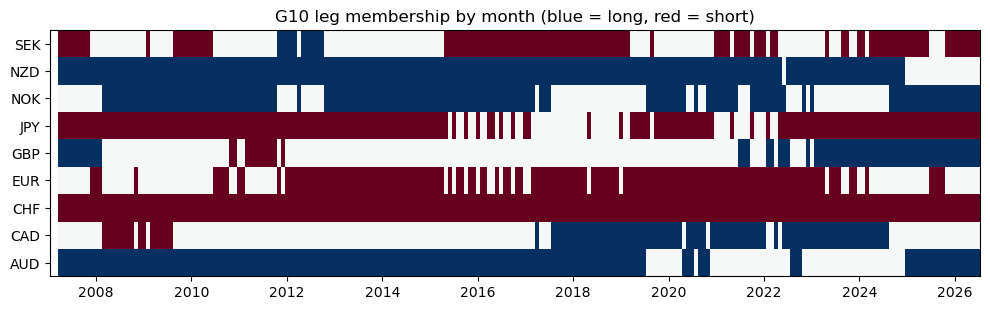

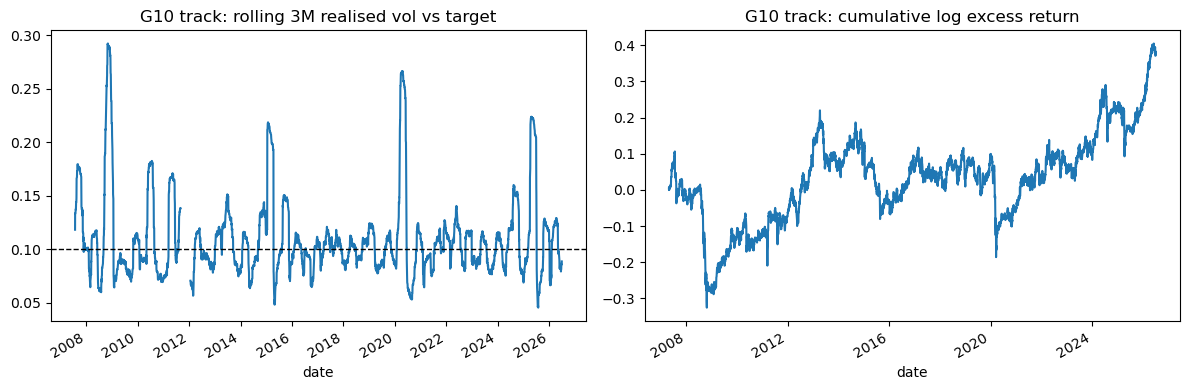

In [3]:
fig, ax = plt.subplots(figsize=(12, 3.2))
m = np.sign(w_g10_unit[UNIVERSE_G10]).resample('ME').last()
ax.pcolormesh(m.index, np.arange(len(m.columns)), m.T.values,
              cmap='RdBu', vmin=-1, vmax=1, shading='nearest')
ax.set_yticks(np.arange(len(m.columns)), m.columns)
ax.set_title('G10 leg membership by month (blue = long, red = short)')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
(g10_gross.rolling(63).std() * np.sqrt(fx.ANN_DAYS)).plot(
    ax=axes[0], title='G10 track: rolling 3M realised vol vs target')
axes[0].axhline(VOL_TARGET, color='k', ls='--', lw=1)
g10_gross.cumsum().plot(ax=axes[1], title='G10 track: cumulative log excess return')
plt.tight_layout()

## 2. Combined G10+EM track — quintiles

Same construction on the 27-currency universe with quintile buckets. The
40%-of-leg single-name cap plus inverse-vol weighting keeps post-2018 TRY (huge
carry, huge vol) from dominating the long leg.

In [4]:
w_all_unit = fx.carry_portfolio(carry, xret, n_buckets=5, universe=UNIVERSE_ALL)
w_all = fx.vol_target_weights(w_all_unit, xret, target=VOL_TARGET)
all_gross = fx.portfolio_returns(w_all, xret, 'ALL_gross')

fx.summary_stats(all_gross.to_frame()).T

,ALL_gross
start,2007-05-01
end,2026-06-30
n_days,5001
ann_return,0.07029
ann_vol,0.111848
daily_variance,0.00005
skew,-0.652152
excess_kurtosis,4.579734
sharpe,0.628442
max_drawdown,-0.267829


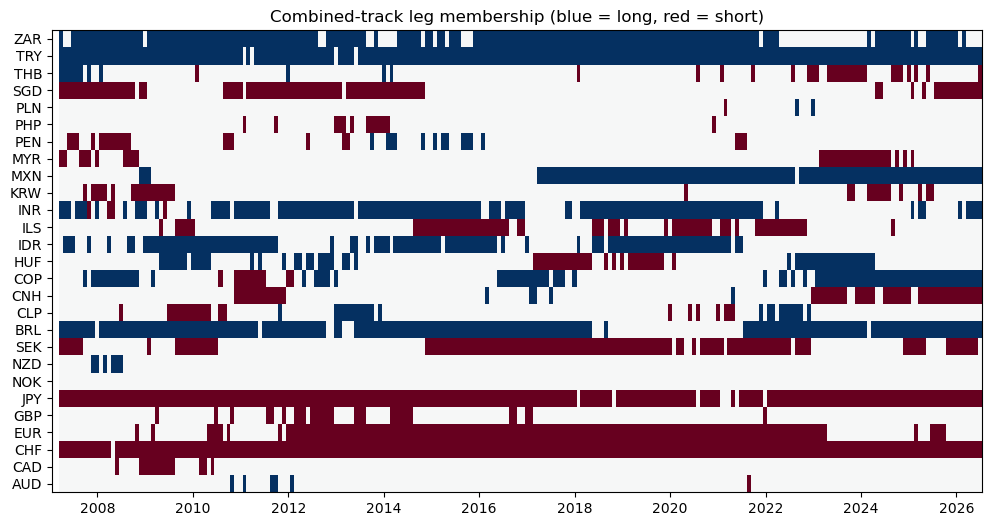

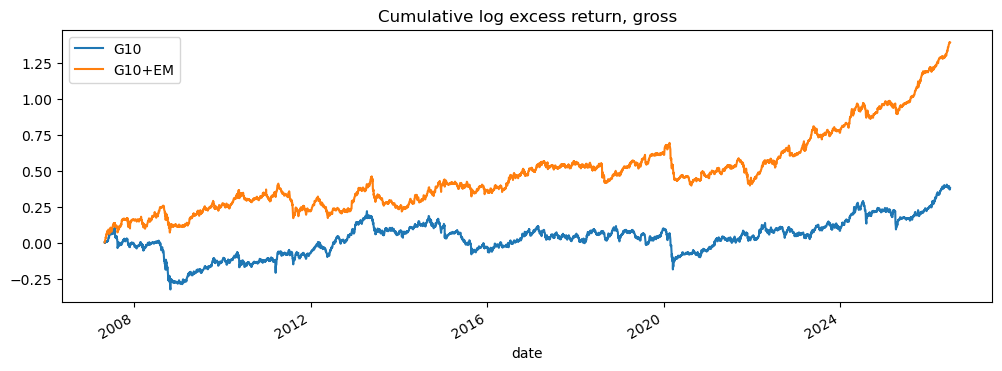

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
m = np.sign(w_all_unit[UNIVERSE_ALL]).resample('ME').last()
ax.pcolormesh(m.index, np.arange(len(m.columns)), m.T.values,
              cmap='RdBu', vmin=-1, vmax=1, shading='nearest')
ax.set_yticks(np.arange(len(m.columns)), m.columns)
ax.set_title('Combined-track leg membership (blue = long, red = short)')
plt.show()

g10_gross.cumsum().plot(label='G10')
all_gross.cumsum().plot(label='G10+EM', title='Cumulative log excess return, gross')
plt.legend();

In [6]:
# Latest post-vol-target weight snapshot; sanity: TRY leg share stays contained
last_w = w_all.dropna(how='all').iloc[-1]
snapshot = last_w[last_w.abs() > 1e-9].sort_values().rename(
    f'weights @ {w_all.dropna(how="all").index[-1].date()}')

try_share = w_all_unit['TRY'].abs().resample('ME').last()
held = try_share[try_share > 0]
print(f'TRY share of its leg when held: mean {held.mean():.1%}, '
      f'max {held.max():.1%} (cap 40%), held {len(held)} months')
snapshot.round(3).to_frame().T

TRY share of its leg when held: mean 20.7%, max 40.0% (cap 40%), held 228 months


,CNH,SGD,CHF,JPY,THB,BRL,COP,MXN,INR,TRY
weights @ 2026-06-30,-1.215,-0.789,-0.517,-0.446,-0.337,0.312,0.391,0.483,0.795,1.321


## 3. Benchmarks & factor regressions

Each track vs its downloaded carry index (`DBHVG10U` for G10, `FXCTEM8` for
EM/combined): information ratio via `fx.summary_stats(..., benchmark=...)`,
plus Newey–West regressions on DOL and HML rebuilt on the restricted 27-ccy
universe — does the vol-targeted sort add alpha over the naive carry factor?

In [7]:
bmk = fx.benchmark_returns()
tracks = pd.concat([g10_gross, all_gross], axis=1)

stats = pd.concat([
    fx.summary_stats(g10_gross.to_frame(), benchmark=bmk['DBHVG10U']),
    fx.summary_stats(all_gross.to_frame(), benchmark=bmk['FXCTEM8']),
    fx.summary_stats(bmk[['DBHVG10U', 'FXCTEM8']]),
])
stats[['start', 'end', 'ann_return', 'ann_vol', 'sharpe',
       'max_drawdown', 'skew', 'info_ratio']].round(3)

,start,end,ann_return,ann_vol,sharpe,max_drawdown,skew,info_ratio
G10_gross,2007-05-01,2026-06-30,0.019263,0.115432,0.166879,-0.365337,-0.953797,0.269403
ALL_gross,2007-05-01,2026-06-30,0.07029,0.111848,0.628442,-0.267829,-0.652152,0.497304
DBHVG10U,2007-01-02,2026-07-06,-0.006832,0.089987,-0.075925,-0.390936,-1.134665,NaN
FXCTEM8,2007-01-02,2026-07-06,0.014665,0.089509,0.163837,-0.320774,-0.258056,NaN


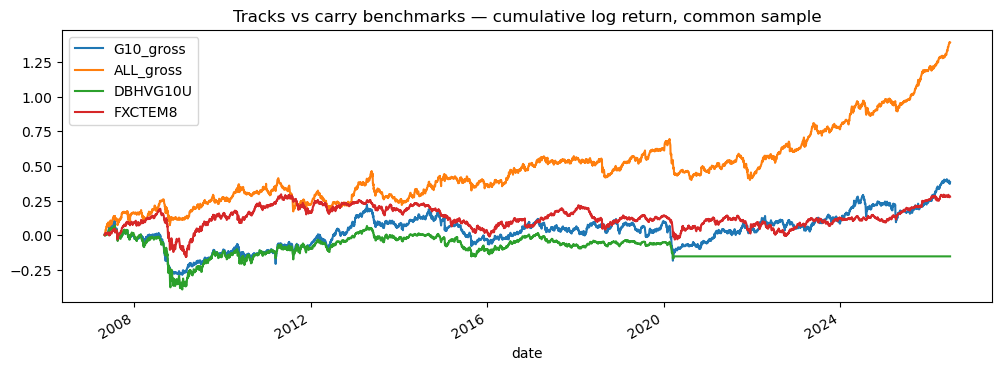

daily correlations (common sample):


,G10_gross,ALL_gross,DBHVG10U,FXCTEM8
G10_gross,1.00,0.53,0.55,0.36
ALL_gross,0.53,1.00,0.34,0.39
DBHVG10U,0.55,0.34,1.00,0.49
FXCTEM8,0.36,0.39,0.49,1.00


In [8]:
common = pd.concat([tracks, bmk[['DBHVG10U', 'FXCTEM8']]], axis=1).dropna()
common.cumsum().plot(title='Tracks vs carry benchmarks — cumulative log return, common sample')
plt.show()
print('daily correlations (common sample):')
common.corr().round(2)

In [9]:
xret_u, carry_u = xret[UNIVERSE_ALL], carry[UNIVERSE_ALL]
factors = pd.concat([fx.dollar_factor(xret_u),
                     fx.carry_hml_factor(xret_u, carry_u)], axis=1)

pd.DataFrame({c: fx.nw_regression(tracks[c], factors) for c in tracks}).T.round(3)

,n,r2,alpha_ann,alpha_t,beta_DOL,t_DOL,beta_HML_FX,t_HML_FX
G10_gross,4994.0,0.310,-0.007,-0.314,0.441,13.016,0.772,16.359
ALL_gross,5001.0,0.686,0.020,1.441,-0.059,-2.276,1.436,39.495


## 4. Transaction costs — actual bid/ask

Half-spreads from the PX_BID/PX_ASK columns: new notional pays the **outright
1M-forward** half-spread (spot + points, both sides), maintained notional rolls
monthly via FX swap and pays only the **points** half-spread. Charged on each
rebalance effective day; net = gross − cost.

In [10]:
hs_out, hs_pts = fx.forward_halfspreads(tenor='1M')

spread_tbl = pd.DataFrame({
    'outright_bps': hs_out.median() * 1e4,
    'points_bps':   hs_pts.median() * 1e4,
}).loc[[c for c in UNIVERSE_ALL if c in hs_out.columns]].sort_values('outright_bps')
spread_tbl.round(1).T

,EUR,JPY,GBP,CAD,AUD,BRL,CHF,INR,CNH,PHP,...,THB,KRW,SEK,COP,NOK,PLN,TRY,ILS,ZAR,HUF
outright_bps,1.0,1.6,1.6,1.7,2.4,2.8,3.0,3.0,3.9,4.0,...,6.0,6.3,7.1,7.1,8.7,9.9,11.3,11.9,12.6,14.8
points_bps,0.1,0.1,0.1,0.1,0.1,0.7,0.2,2.1,0.8,1.0,...,2.3,4.3,0.2,2.3,0.2,0.4,1.6,0.7,0.5,1.2


G10: annualised cost drag 0.55%
G10+EM: annualised cost drag 1.81%


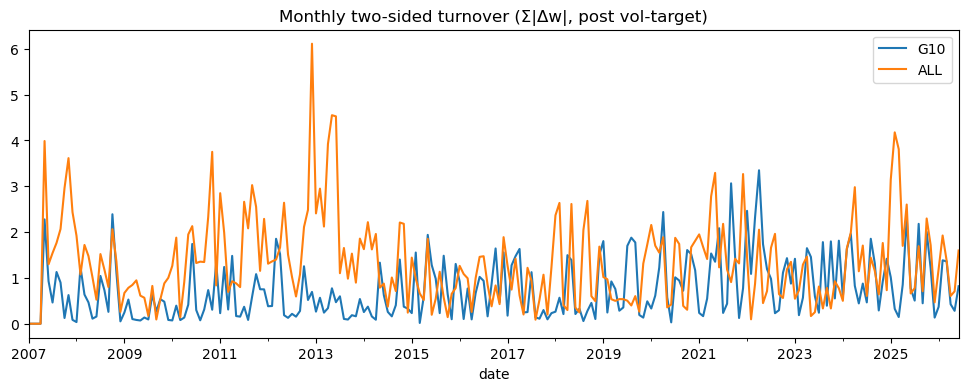

In [11]:
cost_g10 = fx.roundtrip_cost(w_g10, hs_out, hs_pts)
cost_all = fx.roundtrip_cost(w_all, hs_out, hs_pts)
g10_net = (g10_gross - cost_g10).rename('G10_net')
all_net = (all_gross - cost_all).rename('ALL_net')

for name, r, c in (('G10', g10_gross, cost_g10), ('G10+EM', all_gross, cost_all)):
    live = r.dropna().index
    print(f'{name}: annualised cost drag {c.reindex(live).mean() * fx.ANN_DAYS:.2%}')

turnover = pd.DataFrame({'G10': w_g10.fillna(0).diff().abs().sum(axis=1),
                         'ALL': w_all.fillna(0).diff().abs().sum(axis=1)})
turnover.resample('ME').sum().plot(
    title='Monthly two-sided turnover (Σ|Δw|, post vol-target)');

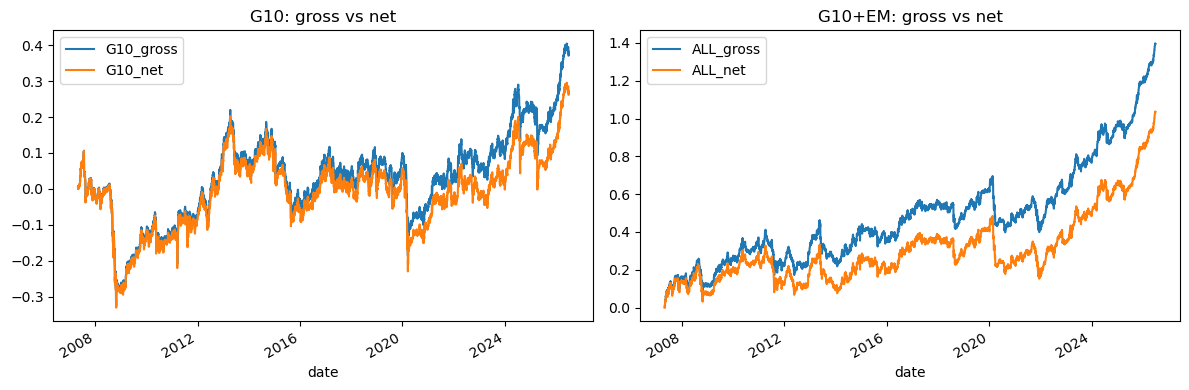

,ann_return,ann_vol,sharpe,max_drawdown
G10_gross,0.019263,0.115432,0.166879,-0.365337
G10_net,0.013756,0.115464,0.119133,-0.382324
ALL_gross,0.07029,0.111848,0.628442,-0.267829
ALL_net,0.052143,0.111914,0.465923,-0.293185


In [12]:
gn = pd.concat([g10_gross, g10_net, all_gross, all_net], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
gn[['G10_gross', 'G10_net']].cumsum().plot(ax=axes[0], title='G10: gross vs net')
gn[['ALL_gross', 'ALL_net']].cumsum().plot(ax=axes[1], title='G10+EM: gross vs net')
plt.tight_layout(); plt.show()

fx.summary_stats(gn)[['ann_return', 'ann_vol', 'sharpe', 'max_drawdown']].round(3)

## 5. Crash-risk overlay

Carry is short crash risk: regress each track on daily changes in aggregate 1M
ATM implied vol, the crash-positive 25Δ risk reversal (positive = FX puts rich
vs USD; FX-first pairs sign-flipped in `vol_surface_panel`), and the EMBI
spread, controlling for DOL/HML. Then a minimal hedged variant: halve next
month's exposure whenever month-end aggregate IV or RR exceeds its trailing
36-month 80th percentile (rolling quantile — no full-sample lookahead).

combined-track options coverage: 21/27 currencies (missing: ['CLP', 'COP', 'IDR', 'MYR', 'PEN', 'PHP'])


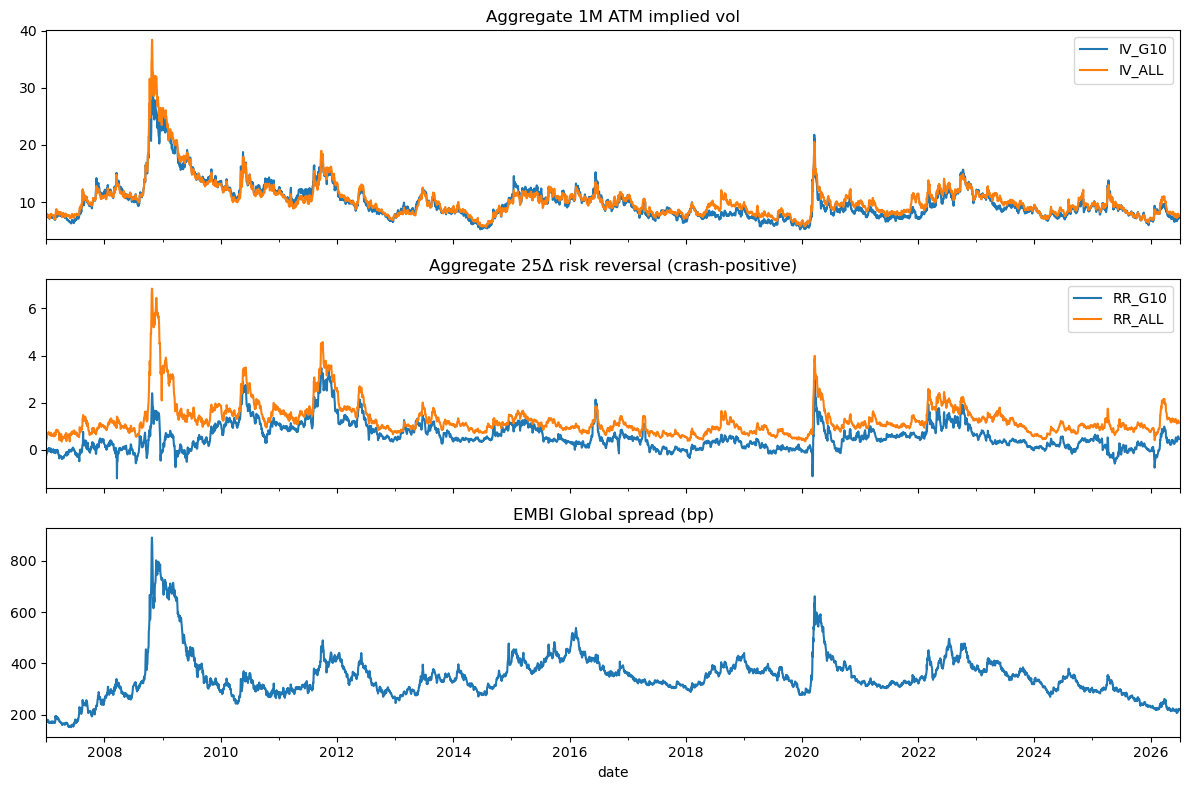

In [13]:
iv = fx.vol_surface_panel('ATM', '1M')
rr = fx.vol_surface_panel('RR', '1M', delta=25)
embi = fx.load_em_risk()

iv_g10 = iv[UNIVERSE_G10].mean(axis=1).rename('IV_G10')
rr_g10 = rr[UNIVERSE_G10].mean(axis=1).rename('RR_G10')
cov_all = [c for c in UNIVERSE_ALL if c in iv.columns]
iv_all = iv[cov_all].mean(axis=1).rename('IV_ALL')
rr_all = rr[cov_all].mean(axis=1).rename('RR_ALL')
print(f'combined-track options coverage: {len(cov_all)}/{len(UNIVERSE_ALL)} currencies '
      f'(missing: {sorted(set(UNIVERSE_ALL) - set(cov_all))})')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
pd.concat([iv_g10, iv_all], axis=1).plot(ax=axes[0], title='Aggregate 1M ATM implied vol')
pd.concat([rr_g10, rr_all], axis=1).plot(ax=axes[1], title='Aggregate 25Δ risk reversal (crash-positive)')
embi.plot(ax=axes[2], title='EMBI Global spread (bp)')
plt.tight_layout()

In [14]:
crash_reg = {}
for name, track, iv_a, rr_a in (('G10_gross', g10_gross, iv_g10, rr_g10),
                                ('ALL_gross', all_gross, iv_all, rr_all)):
    X = pd.concat([iv_a.diff().rename('dIV'), rr_a.diff().rename('dRR'),
                   (embi / 100).diff().rename('dEMBI'), factors], axis=1)
    crash_reg[name] = fx.nw_regression(track, X)
crash_tbl = pd.DataFrame(crash_reg).T
crash_tbl.round(3)

,n,r2,alpha_ann,alpha_t,beta_dIV,t_dIV,beta_dRR,t_dRR,beta_dEMBI,t_dEMBI,beta_DOL,t_DOL,beta_HML_FX,t_HML_FX
G10_gross,4994.0,0.349,-0.002,-0.107,-0.003,-5.976,0.006,2.889,-0.011,-4.068,0.333,10.113,0.619,15.037
ALL_gross,4994.0,0.692,0.022,1.556,-0.001,-1.175,-0.003,-2.067,-0.005,-3.907,-0.139,-5.232,1.392,42.526


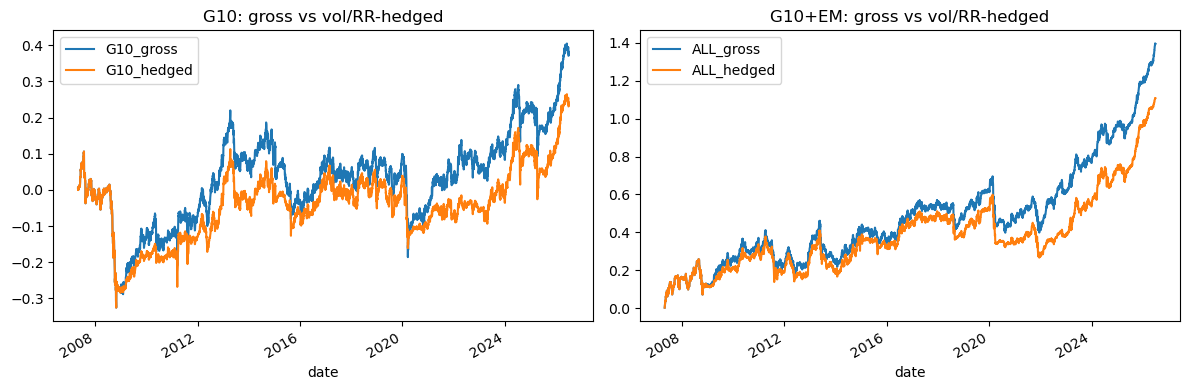

,ann_return,ann_vol,sharpe,max_drawdown,skew,CVaR_99
G10_gross,0.019263,0.115432,0.166879,-0.365337,-0.953797,0.031562
G10_hedged,0.012198,0.102109,0.11946,-0.361625,-0.674014,0.02792
ALL_gross,0.07029,0.111848,0.628442,-0.267829,-0.652152,0.029186
ALL_hedged,0.055806,0.104773,0.532634,-0.290636,-0.791652,0.028877


In [15]:
def hedge_scalar(level, q=0.80, window=36, min_periods=24, scale=0.5):
    """1.0 in calm months, `scale` when the month-end level exceeds its
    trailing `window`-month q-quantile."""
    me = level.resample('ME').last()
    trigger = me > me.rolling(window, min_periods=min_periods).quantile(q)
    return trigger.map({True: scale, False: 1.0})

hedged = {}
for name, track, iv_a, rr_a in (('G10_hedged', g10_gross, iv_g10, rr_g10),
                                ('ALL_hedged', all_gross, iv_all, rr_all)):
    s_me = pd.concat([hedge_scalar(iv_a), hedge_scalar(rr_a)], axis=1).min(axis=1)
    s_daily = s_me.reindex(track.index, method='ffill').shift(1)
    hedged[name] = (track * s_daily).rename(name)
g10_hedged, all_hedged = hedged['G10_hedged'], hedged['ALL_hedged']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.concat([g10_gross, g10_hedged], axis=1).cumsum().plot(ax=axes[0], title='G10: gross vs vol/RR-hedged')
pd.concat([all_gross, all_hedged], axis=1).cumsum().plot(ax=axes[1], title='G10+EM: gross vs vol/RR-hedged')
plt.tight_layout(); plt.show()

fx.summary_stats(pd.concat([g10_gross, g10_hedged, all_gross, all_hedged], axis=1))[
    ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'skew', 'CVaR_99']].round(3)

## 6. Outputs

In [16]:
from pathlib import Path
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

daily = pd.concat([g10_gross, g10_net, g10_hedged,
                   all_gross, all_net, all_hedged,
                   bmk[['DBHVG10U', 'FXCTEM8']]], axis=1)
daily.to_csv(OUT / 'strategy_returns_daily.csv')

summary = pd.concat([
    fx.summary_stats(daily[['G10_gross', 'G10_net', 'G10_hedged']], benchmark=bmk['DBHVG10U']),
    fx.summary_stats(daily[['ALL_gross', 'ALL_net', 'ALL_hedged']], benchmark=bmk['FXCTEM8']),
    fx.summary_stats(bmk[['DBHVG10U', 'FXCTEM8']]),
])
summary.to_csv(OUT / 'strategy_summary_stats.csv')

costs_by_ccy = spread_tbl.join(pd.DataFrame({
    'avg_monthly_turnover_G10': w_g10.fillna(0).diff().abs().resample('ME').sum().mean(),
    'avg_monthly_turnover_ALL': w_all.fillna(0).diff().abs().resample('ME').sum().mean()}))
costs_by_ccy.to_csv(OUT / 'strategy_costs_by_ccy.csv')

crash_tbl.to_csv(OUT / 'crash_regressions.csv')
w_g10.resample('ME').last().to_csv(OUT / 'weights_g10_monthly.csv')
w_all.resample('ME').last().to_csv(OUT / 'weights_combined_monthly.csv')

print('written:', sorted(p.name for p in OUT.glob('*.csv')
                         if p.name.startswith(('strategy_', 'crash_', 'weights_'))))

written: ['crash_regressions.csv', 'strategy_costs_by_ccy.csv', 'strategy_returns_daily.csv', 'strategy_summary_stats.csv', 'weights_combined_monthly.csv', 'weights_g10_monthly.csv']


## 7. Takeaways

- **The carry premium 2007–2026 lives in EM, not G10.** The combined track earns
  7.0%/yr gross at 11.2% vol (Sharpe 0.63); the G10-only track just 1.9%/yr
  (Sharpe 0.17). This mirrors the benchmarks: DBHVG10U was *negative* (−0.7%/yr)
  over the same sample while FXCTEM8 made 1.5%/yr. Both tracks clearly beat
  their benchmark (information ratios 0.27 G10, 0.50 combined) — vol targeting
  and the broader sort add value over the index construction.
- **Construction is validated by the benchmarks**: 0.55 daily correlation with
  DBHVG10U and 0.39 with FXCTEM8 — same trade, better sizing.
- **Against DOL + HML the combined track is ~1.4× levered HML** (R² 0.69) with
  a ~2%/yr alpha (t ≈ 1.4, not significant): the value added is mostly risk
  management (vol scaling), not a new signal — as expected for a carry sort.
- **Costs matter but don't kill it**: annualised drag 0.55% (G10) / 1.81%
  (combined); net Sharpe 0.12 / 0.47. The roll-via-swap treatment is what keeps
  EM viable — points half-spreads are an order of magnitude below outrights.
- **Carry is short crash risk, as the literature says**: both tracks load
  negatively on ΔIV and ΔEMBI (t ≈ −4 to −6); the univariate loading on the
  crash-positive Δ25ΔRR is −0.010 (t ≈ −4.1) for G10. (In the multivariate
  table the G10 dRR sign flips positive because ΔIV — corr 0.38 with ΔRR —
  absorbs the crash variation; collinearity, not a real hedge property.)
- **The simple hedge overlay trims tails, not drawdowns**: halving exposure
  above the trailing 80th percentile of IV/RR cuts G10 CVaR₉₉ from 3.2% to
  2.8% and improves skew (−0.95 → −0.67), but costs more return than risk
  (combined Sharpe 0.63 → 0.53). At these thresholds it is tail insurance, not
  a Sharpe improver — a candidate for refinement (e.g. RR-level conditioning
  per currency) rather than adoption as-is.

**Next steps (HANDOFF §5 complete):** possible extensions — CFTC/IMM
positioning overlay (crowding), per-currency RR conditioning, and a
net-of-cost hedged track combining §4 and §5.